# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## 1. Ranked actions + reason codes

The content action queue ranks pages using the Logistic Regression model's predicted probability of belonging to the declining class.

The highest-ranked pages should be reviewed first because they have the strongest measured model signal for the declining class.

The ranking is a prioritization aid, not a guarantee that a page will decline or that refreshing it will improve performance.

### Reason codes

- HIGH_DECLINE_SIGNAL — high predicted probability of the declining class.
- RECENT_PERFORMANCE — recent traffic/performance signals contribute to the prioritization.
- STALE_CONTENT — the page has been unchanged for a long period.
- REVIEW_REQUIRED — the model signal is not sufficient by itself and human review is required.

### Recommended action levels

| Priority | Suggested action |
|---|---|
| High | Review first |
| Medium | Review after high-priority pages |
| Low | Monitor unless other evidence suggests review |

The reviewer should consider the reason codes together with the page's actual content and search context.

In [10]:
!git clone https://github.com/binitnayak/ml-internship-starter.git

fatal: destination path 'ml-internship-starter' already exists and is not an empty directory.


In [11]:
import os

path = "ml-internship-starter/data/raw/content_refresh_anonymized.csv"

print("Dataset exists:", os.path.exists(path))

Dataset exists: True


In [12]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Dataset path
path = "ml-internship-starter/data/raw/content_refresh_anonymized.csv"

# Load dataset
df = pd.read_csv(path)

# Target
df["target_decline"] = (
    df["trend_direction"] == "down"
).astype(int)

# Features used in ML-08 / ML-09
feature_cols = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

X = df[feature_cols]
y = df["target_decline"]
groups = df["client_id"]

# Client-aware split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train_group = X.iloc[train_idx]
X_test_group = X.iloc[test_idx]

y_train_group = y.iloc[train_idx]
y_test_group = y.iloc[test_idx]

# Same Logistic Regression model from ML-08
group_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train on training clients only
group_model.fit(
    X_train_group,
    y_train_group
)

print("Dataset shape:", df.shape)
print("Training rows:", len(X_train_group))
print("Test rows:", len(X_test_group))
print("Client overlap:", len(
    set(groups.iloc[train_idx]) &
    set(groups.iloc[test_idx])
))

Dataset shape: (30000, 45)
Training rows: 23837
Test rows: 6163
Client overlap: 0


In [13]:
# Create ranked action queue

queue = df.iloc[test_idx].copy()

# Predicted probability of the declining class
queue["decline_probability"] = (
    group_model.predict_proba(X_test_group)[:, 1]
)

# Rank pages from highest to lowest decline probability
queue = queue.sort_values(
    "decline_probability",
    ascending=False
).reset_index(drop=True)

queue["priority_rank"] = range(1, len(queue) + 1)


# Reason codes
def get_reason(row):
    reasons = []

    if row["decline_probability"] >= 0.70:
        reasons.append("HIGH_DECLINE_SIGNAL")

    if row["impressions_last_30d"] < row["impressions_prev_30d"]:
        reasons.append("RECENT_PERFORMANCE")

    if row["days_since_last_update"] > 365:
        reasons.append("STALE_CONTENT")

    if not reasons:
        reasons.append("REVIEW_REQUIRED")

    return "|".join(reasons)


queue["reason_code"] = queue.apply(
    get_reason,
    axis=1
)

# Show top 20
queue[
    [
        "priority_rank",
        "content_id",
        "decline_probability",
        "reason_code"
    ]
].head(20)

,priority_rank,content_id,decline_probability,reason_code
0,1,content_6926821766df,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
1,2,content_cea79ef51519,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
2,3,content_b138c0b35a91,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
3,4,content_453722754fea,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
4,5,content_8c19996aa890,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
5,6,content_4090f0acd977,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
6,7,content_b1bc831deff1,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
7,8,content_8d3971bfd976,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
8,9,content_0919dd345d80,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
9,10,content_617c14bb6cfa,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE


In [14]:
print("Total pages in queue:", len(queue))

print("\nReason code counts:")
print(
    queue["reason_code"]
    .value_counts()
)

print("\nTop 10 priorities:")
display(
    queue[
        [
            "priority_rank",
            "content_id",
            "decline_probability",
            "reason_code"
        ]
    ].head(10)
)

Total pages in queue: 6163

Reason code counts:
reason_code
RECENT_PERFORMANCE                        2624
REVIEW_REQUIRED                           2289
HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE    1245
HIGH_DECLINE_SIGNAL                          5
Name: count, dtype: int64

Top 10 priorities:


,priority_rank,content_id,decline_probability,reason_code
0,1,content_6926821766df,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
1,2,content_cea79ef51519,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
2,3,content_b138c0b35a91,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
3,4,content_453722754fea,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
4,5,content_8c19996aa890,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
5,6,content_4090f0acd977,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
6,7,content_b1bc831deff1,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
7,8,content_8d3971bfd976,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
8,9,content_0919dd345d80,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE
9,10,content_617c14bb6cfa,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE


### Ranked action interpretation

The queue ranks pages by the model's predicted probability of belonging to the declining class.

Pages near the top have the strongest measured model signal and should receive review attention first.

The reason codes provide a simple explanation for prioritization, such as a high decline signal, recent performance change, or stale content.

The ranking is directional. A high probability does not prove that a page will decline, and it does not prove that refreshing the page will improve performance. Each page requires human review before action.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*



### Intended use

This playbook is intended to help a content team prioritize pages for possible refresh.

The Logistic Regression model provides a directional ranking signal based on patterns observed in the available dataset. Pages with a higher predicted probability of the declining class are placed higher in the review queue.

The intended workflow is:

1. Generate the ranked queue.
2. Review the highest-priority pages first.
3. Check the page's current content and search context.
4. Decide whether a refresh is appropriate.
5. Record the human decision.
6. Monitor the page after any approved action.

### Limits

The model was evaluated on the available dataset and should not be treated as a guaranteed predictor of future search performance.

In ML-09, the random split produced an F1 score of 0.8337, while the client-aware split produced an F1 score of 0.7417.

The lower client-aware result shows that performance was harder to maintain when evaluating on unseen clients.

Therefore, this playbook should be used for decision-support and prioritization, not as an automatic content-management system.

A high model probability does not prove that a page will decline, and it does not prove that refreshing the page will improve its performance.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*



### Human review rules

A person must review a page before taking any content action.

The reviewer should check:

- Whether the page's search intent is still relevant.
- Whether the content is actually outdated.
- Whether recent performance changes appear meaningful.
- Whether seasonality or temporary changes could explain the signal.
- Whether the page has important business or informational value.
- Whether a refresh is appropriate for the page.
- Whether the available evidence supports changing the content.

The model ranking should be treated as one input into the decision, not as the final decision.

### What should NOT be automated

This model should not automatically:

- Rewrite content.
- Publish content.
- Delete pages.
- Change search strategy.
- Decide why a page declined.
- Declare that a page will decline in the future.
- Apply a refresh to every high-ranked page.
- Treat model probability as causal evidence.
- Make the final content or business decision.

Human review is required before any action.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*



The recommendations should be monitored because search behavior, content patterns, and traffic distributions can change over time.

### Monitoring

The following signals should be reviewed periodically:

- Distribution of predicted decline probabilities.
- Number of pages entering the high-priority queue.
- False positives and false negatives when new labels become available.
- Precision, recall, and F1 on newly observed labeled data.
- Changes in important feature distributions.
- Whether human reviewers find the recommendations useful.

### Retrain triggers

Retraining should be considered when:

- New labeled data becomes available.
- Validation performance decreases materially.
- Important feature distributions change substantially.
- Search or content behavior changes enough that the original training data may no longer represent the current environment.
- Error patterns change consistently over time.

A single unusual prediction should not automatically trigger retraining. Retraining should be based on repeated evidence that the model or its training data has become stale.

### Cost / value thinking

The main value of the queue is helping reviewers spend limited review time on pages with stronger measured model signals.

Reviewing the highest-ranked pages first can reduce the amount of manual screening required.

However, model priority is not the same as business value. A high-priority page may not be worth refreshing, while a lower-ranked page may have strategic importance.

The final decision should consider review effort, page importance, evidence of outdated content, and the potential value of a refresh.

The model helps allocate attention; it does not guarantee the return from a content refresh.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [15]:
import os

# Create output folders
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Public-safe queue export
export_cols = [
    "priority_rank",
    "content_id",
    "decline_probability",
    "reason_code",
    "content_age_days",
    "days_since_last_update",
    "impressions_last_30d",
    "impressions_prev_30d"
]

queue_export = queue[export_cols].copy()

output_path = "work/outputs/ranked_refresh_queue.csv"

queue_export.to_csv(
    output_path,
    index=False
)

print("Exported:", output_path)
print("Rows:", len(queue_export))

display(queue_export.head(10))

Exported: work/outputs/ranked_refresh_queue.csv
Rows: 6163


,priority_rank,content_id,decline_probability,reason_code,content_age_days,days_since_last_update,impressions_last_30d,impressions_prev_30d
0,1,content_6926821766df,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE,97,20,8154,24401
1,2,content_cea79ef51519,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE,96,20,67474,104722
2,3,content_b138c0b35a91,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE,421,7,6440,16950
3,4,content_453722754fea,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE,97,20,15471,32872
4,5,content_8c19996aa890,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE,445,20,89463,161284
5,6,content_4090f0acd977,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE,421,25,5212,16898
6,7,content_b1bc831deff1,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE,545,25,663,9998
7,8,content_8d3971bfd976,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE,95,20,12652,54506
8,9,content_0919dd345d80,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE,326,7,11057,46296
9,10,content_617c14bb6cfa,1.0,HIGH_DECLINE_SIGNAL|RECENT_PERFORMANCE,445,25,11776,22419




The ranked refresh queue is exported to `work/outputs/ranked_refresh_queue.csv`.

The exported queue contains the priority rank, model probability, reason code, and selected supporting signals needed for the research paper.

Client identifiers are not included in the public-facing export.

The queue is regenerated by the notebook rather than treated as a permanent production dataset.

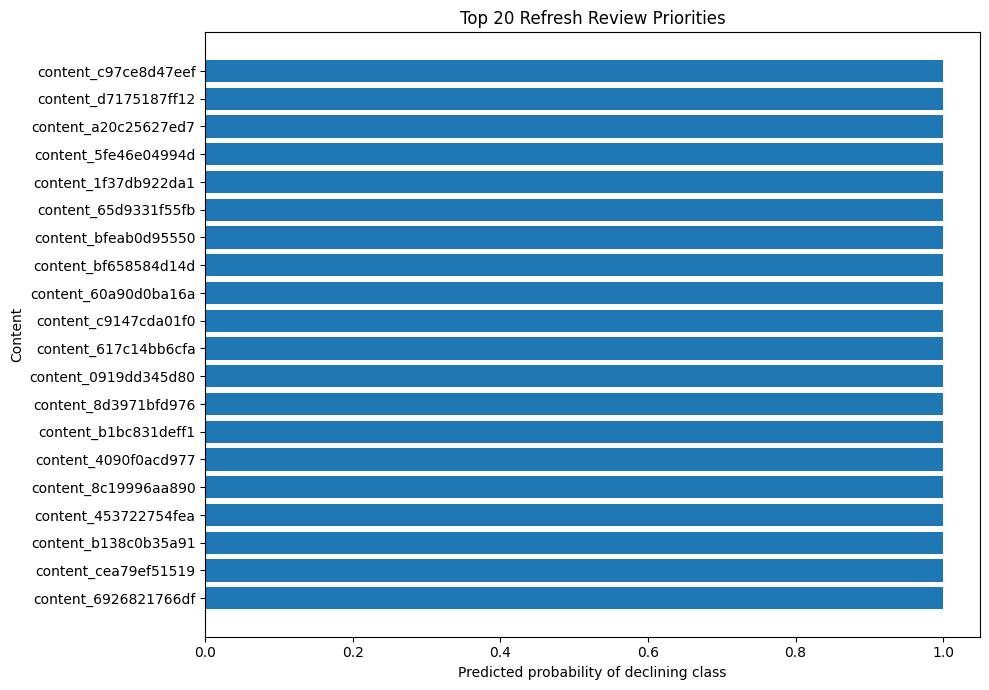

Saved: work/figures/top_refresh_priorities.png


In [16]:
import matplotlib.pyplot as plt

top_n = 20

top_queue = queue.head(top_n).sort_values(
    "decline_probability"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_queue["content_id"].astype(str),
    top_queue["decline_probability"]
)

plt.xlabel("Predicted probability of declining class")
plt.ylabel("Content")
plt.title("Top 20 Refresh Review Priorities")

plt.tight_layout()

figure_path = "work/figures/top_refresh_priorities.png"

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

### Figure interpretation

The figure shows the 20 highest-ranked pages in the review queue based on the model's predicted probability of the declining class.

The probabilities are a ranking signal produced by the model. They should not be interpreted as a guarantee that these pages will decline or that refreshing them will improve performance.

The figure is intended to support human review and can be reused in the research paper as a visual summary of the prioritization approach.

## Self-check

- [x] Ranked actions are included.
- [x] Reason codes are included.
- [x] Intended use is explained.
- [x] Model limits are explained.
- [x] Human review rules are included.
- [x] No-go automation cases are listed.
- [x] Monitoring triggers are defined.
- [x] Retrain triggers are defined.
- [x] Cost/value thinking is addressed.
- [x] Ranked queue is exported to `work/outputs/`.
- [x] Reusable figure is exported to `work/figures/`.
- [ ] Runtime → Run all completes without errors.
- [ ] No client names, URLs, or private queries are included.
- [ ] Notebook is saved as `work/notebooks/w07_action_playbook.ipynb`.
- [ ] Notebook is committed and pushed to the repository.